---
title: "Rank credit default risk: TabPFN 3 vs 3.5"
description: "Compare ROC-AUC against XGBoost when ranking next-month credit default risk."
cookbookTags:
  - classification
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

A lender needs to identify which customers are most likely to default next month. Here we rank credit-card default risk from payment history, bill amounts, and customer attributes. Better risk ranking can help prioritize review and monitoring, so we compare how well each model separates defaulters from non-defaulters.

## Setup

Install the dependencies in a fresh Python kernel. Compare TabPFN 3 and 3.5 with standard inference and high thinking effort. Timings include network and queue latency. Set `thinking_metric="roc_auc"` so thinking optimizes the same metric shown in the results.

Authenticate using the [quickstart](https://docs.priorlabs.ai/cookbook/quickstart), or set `TABPFN_TOKEN` in your local environment before running the notebook.

In [ ]:
%pip install -q --upgrade tabpfn-client "pandas==2.3.3" "numpy==2.4.6" "scikit-learn==1.9.0" "matplotlib==3.11.1" "xlrd==2.0.2" "xgboost==3.2.0"

In [1]:
import time
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from tabpfn_client.models import ApiMode

VERSIONS = {"TabPFN 3": ModelVersion.V3, "TabPFN 3.5": ModelVersion.V3_5}
VARIANTS = [(name, thinking) for name in VERSIONS for thinking in (False, True)]
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

def archive(url):
    return ZipFile(BytesIO(urlopen(url).read()))

The helpers below keep model settings and chart colors consistent across variants.

In [2]:
def model_for(cls, name, thinking=False, **kwargs):
    return cls.create_default_for_version(
        VERSIONS[name], n_estimators=4, random_state=42,
        api_mode=ApiMode.ASYNC if thinking else ApiMode.AUTO,
        thinking_effort="high" if thinking else None,
        thinking_metric="roc_auc" if thinking else None, **kwargs,
    )

def performance_bars(results, metric, direction):
    colors = {"TabPFN 3": "#90a4ae", "TabPFN 3 + thinking high": "#5c6bc0",
              "TabPFN 3.5": "#80cbc4", "TabPFN 3.5 + thinking high": "#00897b",
              "XGBoost": "#bcaaa4"}
    values = results[metric].iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(values.index, values, color=[colors[name] for name in values.index])
    ax.set(xlabel=f"{metric} ({direction} is better)", ylabel="")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    low, high = values.min(), values.max()
    if low > 0 and high - low < 0.2 * high:
        padding = max((high - low) * 0.3, high * 0.01, 0.001)
        ax.set_xlim(max(0, low - padding), high + 2 * padding)
        ax.set_title("Zoomed axis (does not start at zero)", fontsize=9)
    else:
        ax.set_xlim(0, high * 1.22)
    fig.tight_layout()
    plt.show()


## Data and split

[UCI Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) contains 30,000 clients and 23 predictors. Remove the row ID and use a stratified split of 24,000 training and 6,000 test rows. Every model uses the same split, and test labels never enter fitting.

In [3]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

with archive("https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip") as z:
    df = pd.read_excel(z.open("default of credit card clients.xls"), header=1)
X, y = df.drop(columns=["ID", "default payment next month"]), df["default payment next month"]
train, test = train_test_split(np.arange(len(y)), test_size=6000, stratify=y, random_state=42)
X_train, X_test = X.iloc[train], X.iloc[test]
y_train, y_test = y.iloc[train], y.iloc[test]
cat_indices = [X.columns.get_loc(k) for k in ["SEX", "EDUCATION", "MARRIAGE"]]
assert X.shape == (30000, 23) and not set(train) & set(test)
print(f"Train / test: {len(train)} / {len(test)}")

Train / test: 24000 / 6000


## Compare

Compare a fixed XGBoost baseline with all four TabPFN variants. Thinking optimizes `roc_auc`, and all models are evaluated on their predicted probabilities without post-hoc calibration. **ROC-AUC** measures how well defaulters rank above non-defaulters across thresholds; higher is better.

In [4]:
rows, predictions = [], {}
for name, thinking in VARIANTS + [("XGBoost", False)]:
    label = name + (" + thinking high" if thinking else "")
    start = time.perf_counter()
    model = (XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05,
                           tree_method="hist", device="cpu", n_jobs=8, random_state=42)
             if name == "XGBoost" else model_for(TabPFNClassifier, name, thinking,
                                                categorical_features_indices=cat_indices))
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    predictions[label] = p
    rows.append({"Model": label, "ROC-AUC": roc_auc_score(y_test, p),
                 "Seconds": time.perf_counter() - start})
    print(f"Finished {label}")
all_results = pd.DataFrame(rows).set_index("Model")

Train set already exists, skipping upload.


Finished TabPFN 3


Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished TabPFN 3 + thinking high


...

Train set already exists, skipping upload.


Finished TabPFN 3.5


Test set already exists, skipping upload.


Finished TabPFN 3.5 + thinking high


Finished XGBoost


## Results

TabPFN 3.5 improves ROC-AUC from 0.7837 to 0.7866 compared with v3. Thinking optimized for ROC-AUC improves both versions, to 0.7851 and 0.7869 respectively, while XGBoost scores 0.7762. The differences between TabPFN variants are modest, but v3.5 with thinking ranks default risk best on these 6,000 held-out customers.

In [5]:
display(all_results[["ROC-AUC"]].round(4))

,ROC-AUC
Model,
TabPFN 3,0.7837
TabPFN 3 + thinking high,0.7851
TabPFN 3.5,0.7866
TabPFN 3.5 + thinking high,0.7869
XGBoost,0.7762


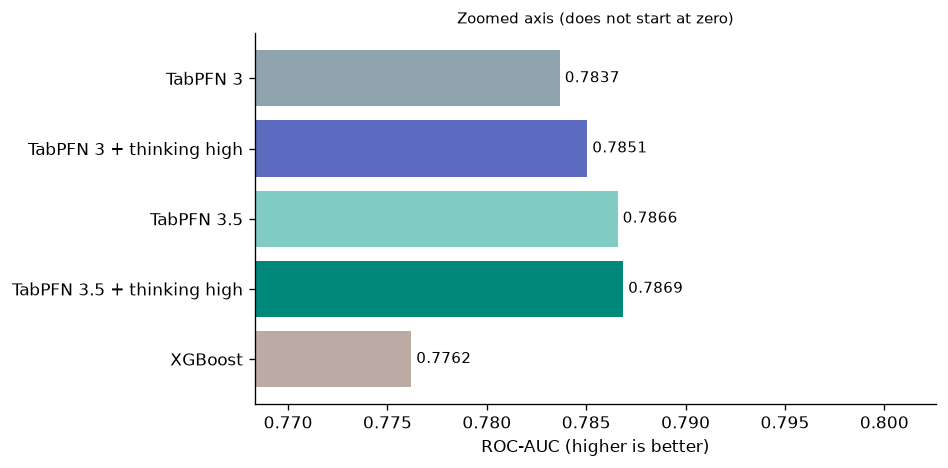

In [6]:
performance_bars(all_results, "ROC-AUC", "higher")

### What to take away

The newer model and thinking both improve risk ranking in this run, using predicted probabilities directly. ROC-AUC evaluates ranking rather than the accuracy of absolute default probabilities; the result describes one historical population and split.